# Speech and image analysis course project



## Importing libraries

In [83]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
from scipy import signal
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import os
from glob import glob


In [84]:
DATASET_PATH = "C:\\Users\\rahul\\Downloads\\AudioMNIST-master\\AudioMNIST-master\\data"

In [85]:
import os

wav_files = []

for speaker in os.listdir(DATASET_PATH):
    speaker_path = os.path.join(DATASET_PATH, speaker)
    
    if os.path.isdir(speaker_path):
        for file in os.listdir(speaker_path):
            if file.endswith(".wav"):
                wav_files.append(os.path.join(speaker_path, file))

print("Total WAV files:", len(wav_files))
print("First 5 files:", wav_files[:5])


Total WAV files: 30000
First 5 files: ['C:\\Users\\rahul\\Downloads\\AudioMNIST-master\\AudioMNIST-master\\data\\01\\0_01_0.wav', 'C:\\Users\\rahul\\Downloads\\AudioMNIST-master\\AudioMNIST-master\\data\\01\\0_01_1.wav', 'C:\\Users\\rahul\\Downloads\\AudioMNIST-master\\AudioMNIST-master\\data\\01\\0_01_10.wav', 'C:\\Users\\rahul\\Downloads\\AudioMNIST-master\\AudioMNIST-master\\data\\01\\0_01_11.wav', 'C:\\Users\\rahul\\Downloads\\AudioMNIST-master\\AudioMNIST-master\\data\\01\\0_01_12.wav']


### why we store the files as full paths?

To ensure reliable access to audio files and reduce ambiguity across audio files across directory structures and execution environments

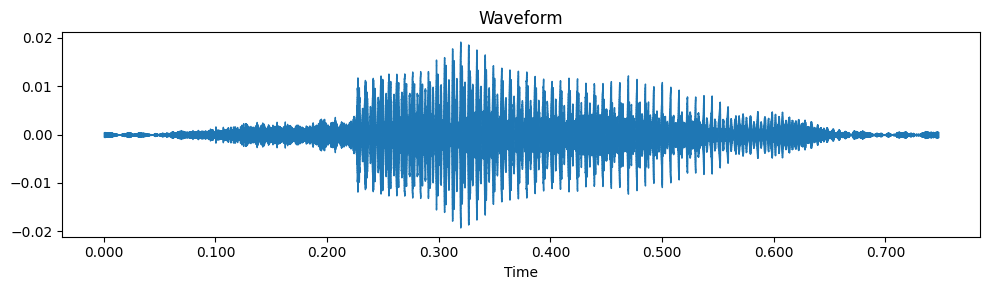

In [86]:
y, sr = librosa.load(wav_files[0], sr=None)

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.tight_layout()
plt.show()

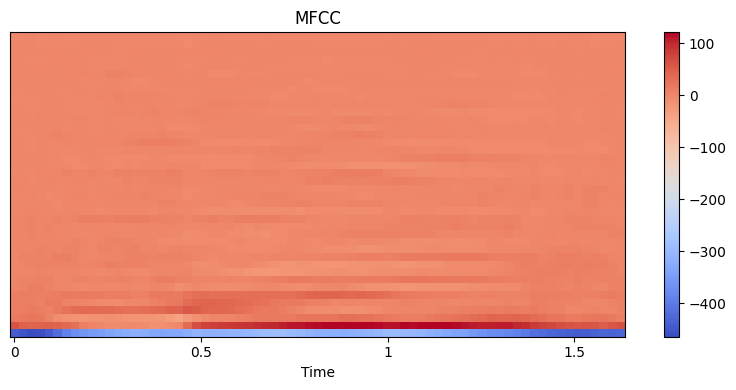

In [87]:
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40,n_mels=40)

plt.figure(figsize=(8, 4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC")
plt.tight_layout()
plt.show()


In [88]:
np.set_printoptions(
    precision=2,
    suppress=True,
    linewidth=120
)

print("MFCC Coefficients (first 5 frames):\n")
print(mfcc[:5])

MFCC Coefficients (first 5 frames):

[[-439.99 -452.65 -464.79 -461.98 -445.29 -420.47 -390.77 -372.67 -363.03 -354.17 -346.99 -338.29 -328.48 -323.35
  -320.11 -323.32 -332.25 -335.86 -331.59 -331.03 -322.4  -311.19 -313.35 -314.31 -312.24 -310.73 -307.04 -302.91
  -298.92 -295.04 -291.88 -293.19 -296.13 -301.12 -309.82 -316.11 -317.84 -320.26 -320.7  -317.55 -314.76 -310.84
  -305.76 -297.48 -295.54 -300.3  -302.89 -307.77 -316.83 -324.04 -330.9  -336.83 -343.01 -354.99 -365.11 -373.87
  -376.69 -383.58 -391.21 -401.36 -414.75 -422.6  -429.61 -435.04 -438.32 -441.94 -440.24 -432.86 -429.14 -431.59
  -428.38]
 [  59.18   46.8    41.49   43.05   46.86   44.13   37.2    27.06   10.66    3.27   -1.36   -5.54   -4.87   -4.3
    -4.78   -5.98  -12.27  -13.19   -7.91   -1.38   34.71   66.66   78.81   81.51   84.45   87.99   90.61   93.33
    95.2    98.59  101.55  106.92  110.78  110.97  114.31  117.67  119.04  119.96  120.55  119.34  120.58  118.72
   116.75  112.23  113.81  119.24  118.45

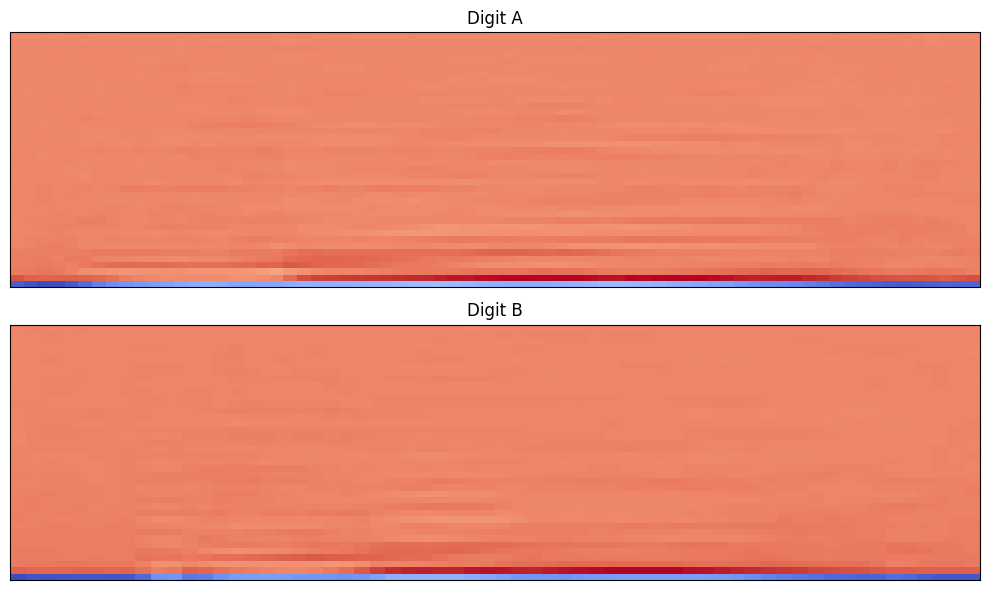

In [89]:
y1, _ = librosa.load(wav_files[0], sr=None)
y2, _ = librosa.load(wav_files[1000], sr=None)

mfcc1 = librosa.feature.mfcc(y=y1, sr=sr, n_mfcc=40,n_mels=40)
mfcc2 = librosa.feature.mfcc(y=y2, sr=sr, n_mfcc=40,n_mels=40)

plt.figure(figsize=(10, 6))

plt.subplot(2,1,1)
librosa.display.specshow(mfcc1)
plt.title("Digit A")

plt.subplot(2,1,2)
librosa.display.specshow(mfcc2)
plt.title("Digit B")

plt.tight_layout()
plt.show()


In [90]:
y_trimmed, _ = librosa.effects.trim(y)
y_norm = librosa.util.normalize(y_trimmed)

## Extracting the MFCC Coefficients

In [127]:
def extract_mfcc_ml(file_path, n_mfcc=40):
    y, sr = librosa.load(file_path, sr=None)

    # Trim silence
    y, _ = librosa.effects.trim(y)

    # Normalize
    y = librosa.util.normalize(y).astype(np.float32)

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Aggregate over time (ML requirement)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std  = mfcc.std(axis=1)

    # Final feature vector
    features = np.hstack([mfcc_mean, mfcc_std])  # (80,)

    return features


In [128]:
X = []
speaker_labels = []

for file in wav_files:
    X.append(extract_mfcc_ml(file))

    # filename: digit_speaker_index.wav
    speaker_id = os.path.basename(file).split("_")[1]
    speaker_labels.append(speaker_id)

X = np.array(X)
speaker_labels = np.array(speaker_labels)

print("Feature shape:", X.shape)
print("Total speakers:", len(set(speaker_labels)))


Feature shape: (30000, 80)
Total speakers: 60


In [130]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(speaker_labels)

print("Encoded speaker classes:", len(np.unique(y)))

Encoded speaker classes: 60


In [169]:
print(y)

[ 0  0  0 ... 59 59 59]


## Splitting training and testing

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)


(24000, 80) (6000, 80)


## Scaling

In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


## SVM

In [133]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm.fit(X_train_scaled, y_train)


SVC(C=10)

In [134]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9976666666666667

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00       100
           4       1.00      1.00      1.00       100
           5       1.00      1.00      1.00       100
           6       0.99      0.99      0.99       100
           7       1.00      1.00      1.00       100
           8       1.00      1.00      1.00       100
           9       0.99      1.00      1.00       100
          10       1.00      1.00      1.00       100
          11       0.99      1.00      1.00       100
          12       1.00      1.00      1.00       100
          13       1.00      0.98      0.99       100
          14       1.00      0.99      0.99       100
          15       1.00      1.00      1.00       100
          16       1.00    

In [139]:
#Confusion matrix
from sklearn.metrics import confusion_matrix

cm_SVC = confusion_matrix(y_test, y_pred)
print("Confusion Matrix {SVC Model}:\n", cm_SVC)


Confusion Matrix {SVC Model}:
 [[100   0   0 ...   0   0   0]
 [  0 100   0 ...   0   0   0]
 [  0   0 100 ...   0   0   0]
 ...
 [  0   0   0 ... 100   0   0]
 [  0   0   0 ...   0 100   0]
 [  0   0   0 ...   0   0 100]]


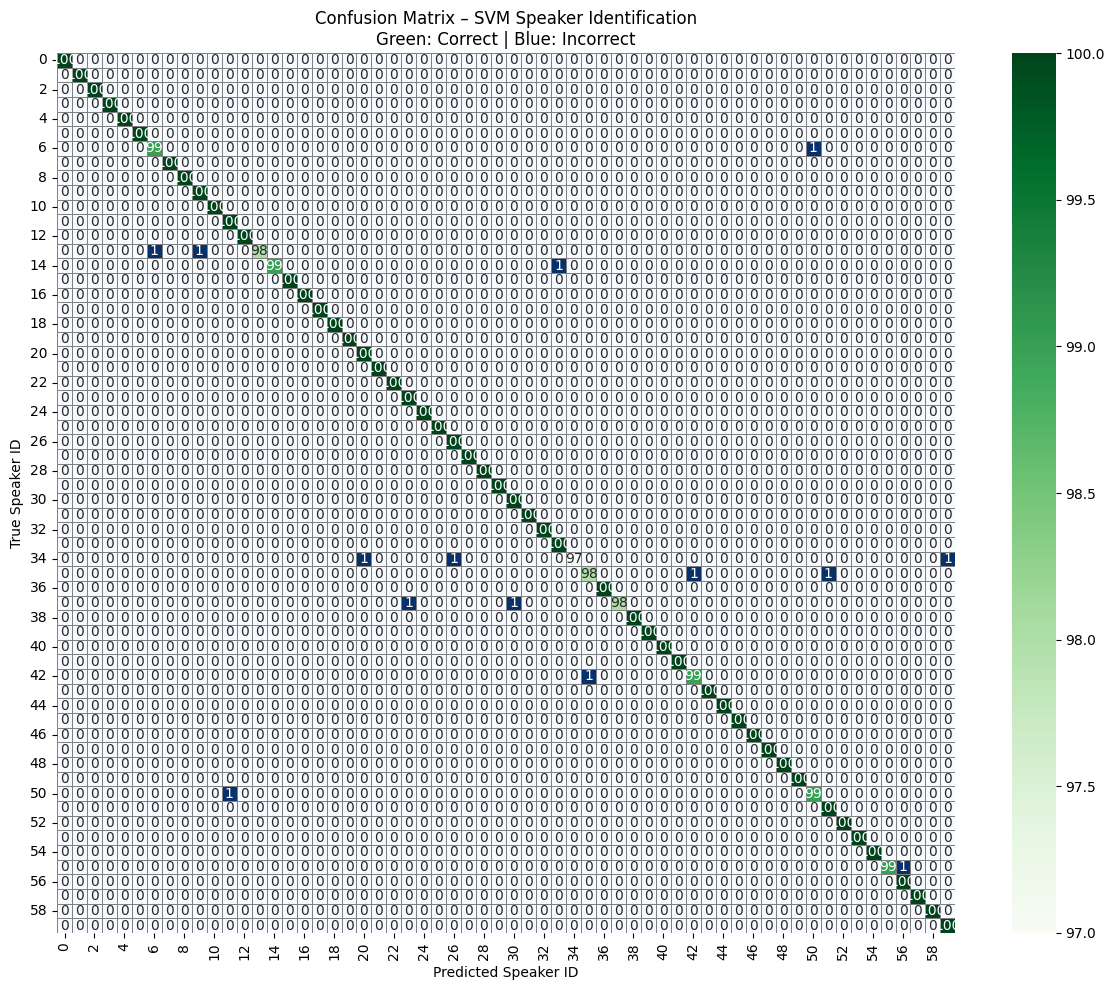

In [140]:
labels = np.unique(y_test)
diag = np.eye(cm_SVC.shape[0], dtype=bool)

plt.figure(figsize=(12, 10))

# Correct predictions (diagonal) → GREEN
sns.heatmap(
    cm_SVC,
    mask=~diag,
    cmap="Greens",
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.4,
    linecolor="gray"
)

# Incorrect predictions (off-diagonal) → BLUE
sns.heatmap(
    cm_SVC,
    mask=diag,
    cmap="Blues",
    annot=True,
    fmt="d",
    cbar=False,
    linewidths=0.4,
    linecolor="gray"
)

plt.xlabel("Predicted Speaker ID")
plt.ylabel("True Speaker ID")
plt.title("Confusion Matrix – SVM Speaker Identification\nGreen: Correct | Blue: Incorrect")

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [148]:
total_samples = cm_SVC.sum()
correct_preds = np.trace(cm_SVC)
errors = total_samples - correct_preds

print("Total test samples:", total_samples)
print("Correct predictions:", correct_preds)
print("Misclassifications:", errors)
print("Accuracy from CM:", correct_preds / total_samples)


Total test samples: 6000
Correct predictions: 5986
Misclassifications: 14
Accuracy from CM: 0.9976666666666667


## KNN

In [213]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# KNN classifier
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="euclidean"
)

# Train
knn.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn.predict(X_test_scaled)

# Evaluate
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Speaker Accuracy:", knn_accuracy)
print("classification report \n",classification_report(y_test, y_pred_knn))

KNN Speaker Accuracy: 0.9935
classification report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100
           2       0.99      1.00      1.00       100
           3       1.00      1.00      1.00       100
           4       1.00      1.00      1.00       100
           5       1.00      1.00      1.00       100
           6       0.99      0.98      0.98       100
           7       1.00      1.00      1.00       100
           8       1.00      1.00      1.00       100
           9       1.00      1.00      1.00       100
          10       1.00      1.00      1.00       100
          11       1.00      0.98      0.99       100
          12       0.99      1.00      1.00       100
          13       0.99      0.98      0.98       100
          14       1.00      0.96      0.98       100
          15       1.00      1.00      1.00       100
          16       0.98     

In [151]:
from sklearn.metrics import precision_score, recall_score, f1_score

knn_precision = precision_score(y_test, y_pred_knn, average="macro")
knn_recall    = recall_score(y_test, y_pred_knn, average="macro")
knn_f1        = f1_score(y_test, y_pred_knn, average="macro")

print("KNN Precision:", knn_precision)
print("KNN Recall:", knn_recall)
print("KNN F1-score:", knn_f1)
print("classification report \n",classification_report(y_test, y_pred_knn))

KNN Precision: 0.9936148730095941
KNN Recall: 0.9935000000000002
KNN F1-score: 0.9934930730319934
classification report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100
           2       0.99      1.00      1.00       100
           3       1.00      1.00      1.00       100
           4       1.00      1.00      1.00       100
           5       1.00      1.00      1.00       100
           6       0.99      0.98      0.98       100
           7       1.00      1.00      1.00       100
           8       1.00      1.00      1.00       100
           9       1.00      1.00      1.00       100
          10       1.00      1.00      1.00       100
          11       1.00      0.98      0.99       100
          12       0.99      1.00      1.00       100
          13       0.99      0.98      0.98       100
          14       1.00      0.96      0.98       100
          15 

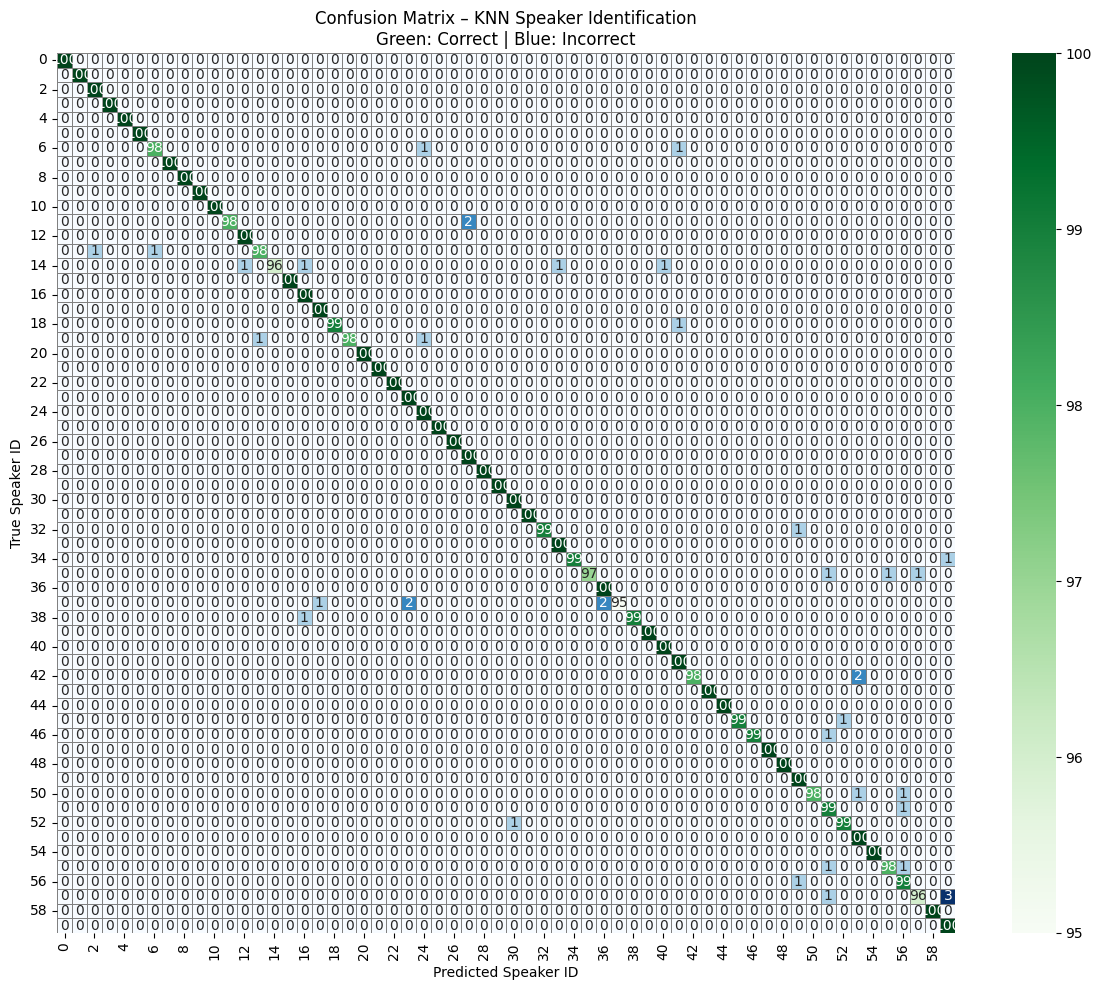

In [145]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
labels = np.unique(y_test)
diag = np.eye(cm_knn.shape[0], dtype=bool)

plt.figure(figsize=(12,10))

# Correct predictions → GREEN
sns.heatmap(
    cm_knn,
    mask=~diag,
    cmap="Greens",
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.4,
    linecolor="gray"
)

# Incorrect predictions → BLUE
sns.heatmap(
    cm_knn,
    mask=diag,
    cmap="Blues",
    annot=True,
    fmt="d",
    cbar=False,
    linewidths=0.4,
    linecolor="gray"
)

plt.xlabel("Predicted Speaker ID")
plt.ylabel("True Speaker ID")
plt.title("Confusion Matrix – KNN Speaker Identification\nGreen: Correct | Blue: Incorrect")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [147]:
total_samples = cm_knn.sum()
correct_preds = np.trace(cm_knn)
errors = total_samples - correct_preds

print("Total test samples:", total_samples)
print("Correct predictions:", correct_preds)
print("Misclassifications:", errors)
print("Accuracy from CM:", correct_preds / total_samples)


Total test samples: 6000
Correct predictions: 5961
Misclassifications: 39
Accuracy from CM: 0.9935


## Random Forest

In [152]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
# Train
rf.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf.predict(X_test_scaled)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9886666666666667

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       100
           1       1.00      0.99      0.99       100
           2       0.99      0.99      0.99       100
           3       1.00      1.00      1.00       100
           4       0.98      1.00      0.99       100
           5       0.99      1.00      1.00       100
           6       0.99      0.98      0.98       100
           7       1.00      1.00      1.00       100
           8       0.99      1.00      1.00       100
           9       1.00      1.00      1.00       100
          10       0.99      0.99      0.99       100
          11       0.96      0.99      0.98       100
          12       0.98      1.00      0.99       100
          13       1.00      0.98      0.99       100
          14       0.99      0.98      0.98       100
          15       0.99      1.00      1.00       100

In [102]:
rf_precision = precision_score(y_test, y_pred_rf, average="macro")
rf_recall    = recall_score(y_test, y_pred_rf, average="macro")
rf_f1        = f1_score(y_test, y_pred_rf, average="macro")

print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1-score:", rf_f1)


Random Forest Precision: 0.991507733449615
Random Forest Recall: 0.9915
Random Forest F1-score: 0.9914888484548016


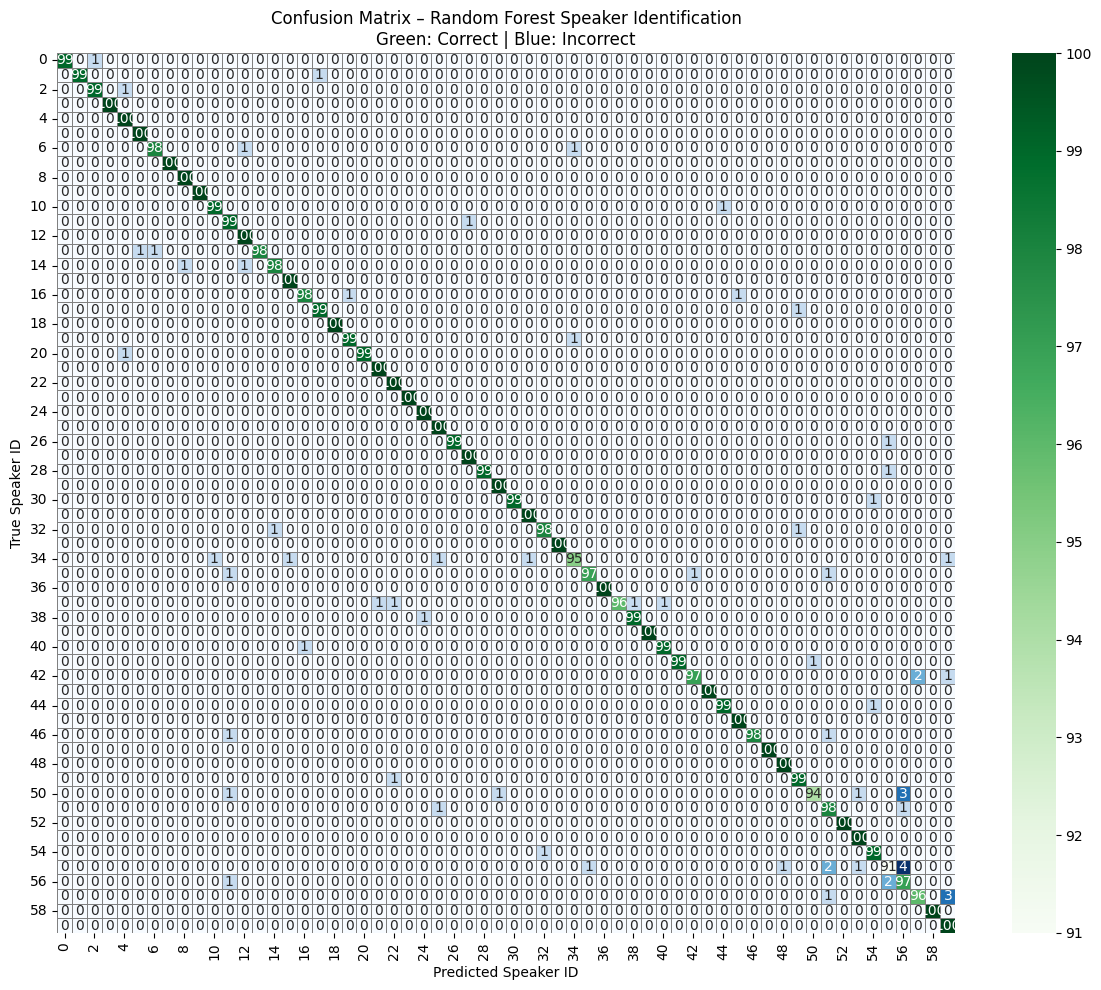

In [153]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
labels = np.unique(y_test)
diag = np.eye(cm_rf.shape[0], dtype=bool)

plt.figure(figsize=(12,10))

# Correct predictions → GREEN
sns.heatmap(
    cm_rf,
    mask=~diag,
    cmap="Greens",
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.4,
    linecolor="gray"
)

# Incorrect predictions → BLUE
sns.heatmap(
    cm_rf,
    mask=diag,
    cmap="Blues",
    annot=True,
    fmt="d",
    cbar=False,
    linewidths=0.4,
    linecolor="gray"
)

plt.xlabel("Predicted Speaker ID")
plt.ylabel("True Speaker ID")
plt.title("Confusion Matrix – Random Forest Speaker Identification\nGreen: Correct | Blue: Incorrect")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [154]:
total_samples = cm_rf.sum()
correct_preds = np.trace(cm_rf)
errors = total_samples - correct_preds

print("Total test samples:", total_samples)
print("Correct predictions:", correct_preds)
print("Misclassifications:", errors)
print("Accuracy from CM:", correct_preds / total_samples)


Total test samples: 6000
Correct predictions: 5932
Misclassifications: 68
Accuracy from CM: 0.9886666666666667


In [156]:
model_scores = {
    "SVM (RBF)": svm_accuracy,
    "KNN": knn_accuracy,
    "Random Forest": rf_accuracy,
}

for model, score in model_scores.items():
    print(f"{model}: {score:.4f}")


SVM (RBF): 0.9985
KNN: 0.9935
Random Forest: 0.9915


In [157]:
import pandas as pd

results_df = pd.DataFrame.from_dict(
    model_scores,
    orient="index",
    columns=["Accuracy"]
)

results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Accuracy
SVM (RBF),0.9985
KNN,0.9935
Random Forest,0.9915


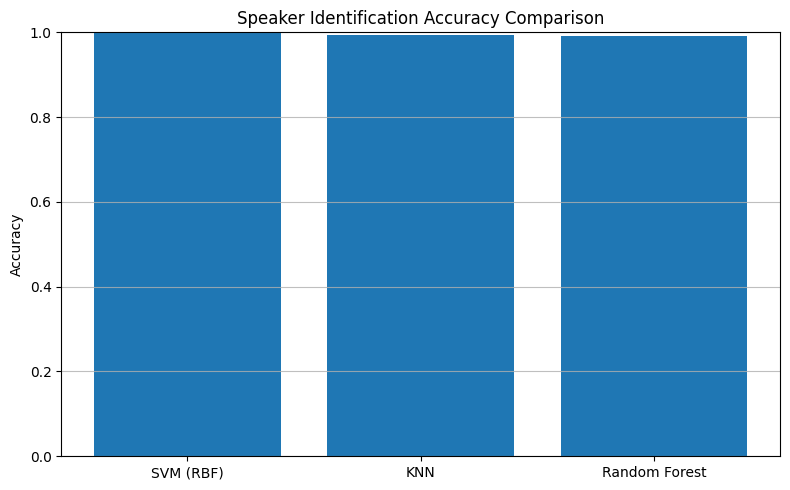

In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df.index, results_df["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Speaker Identification Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.8)
plt.tight_layout()
plt.show()


### DL Models

In [ ]:
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [ ]:
y_trimmed, _ = librosa.effects.trim(y)
y_norm = librosa.util.normalize(y_trimmed)
y_norm = y_norm.astype(np.float32)

In [166]:
mfcc = librosa.feature.mfcc(
    y=y_norm,
    sr=sr,
    n_mfcc=40
)

print(mfcc.shape)

(40, 71)


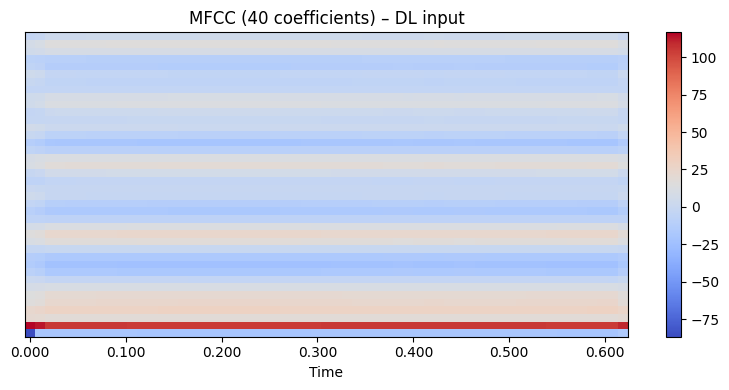

In [ ]:
plt.figure(figsize=(8, 4))
librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)
plt.colorbar()
plt.title("MFCC (40 coefficients) – DL input")
plt.tight_layout()
plt.show()

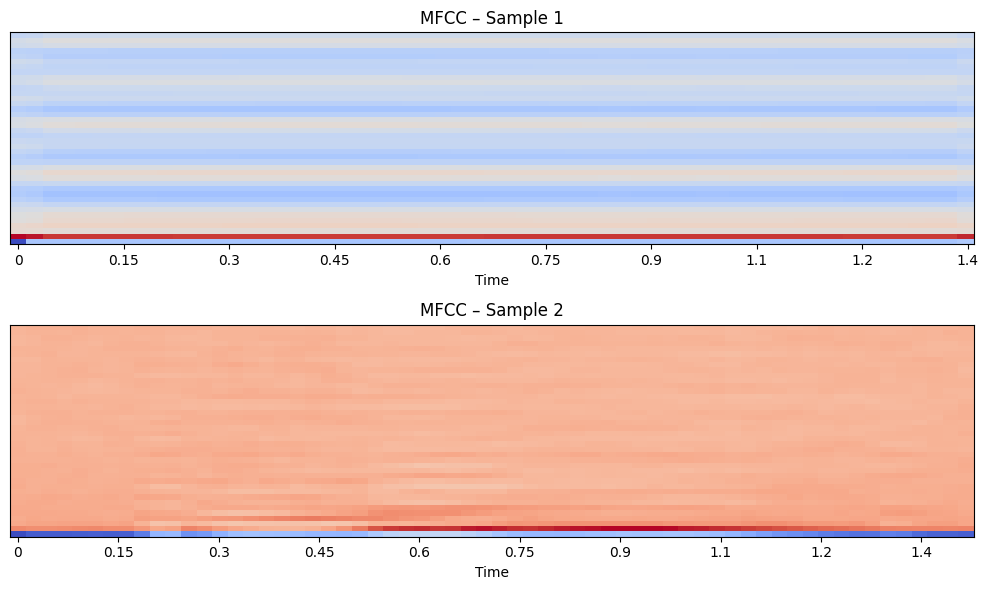

In [ ]:
y2, sr2 = librosa.load(wav_files[1000], sr=None)
y2, _ = librosa.effects.trim(y2)
y2 = librosa.util.normalize(y2)

mfcc2 = librosa.feature.mfcc(y=y2, sr=sr2, n_mfcc=40)

plt.figure(figsize=(10, 6))

plt.subplot(2,1,1)
librosa.display.specshow(mfcc, x_axis="time")
plt.title("MFCC – Sample 1")

plt.subplot(2,1,2)
librosa.display.specshow(mfcc2, x_axis="time")
plt.title("MFCC – Sample 2")

plt.tight_layout()
plt.show()


In [ ]:
def extract_mfcc_dl(file_path, n_mfcc=40, max_len=100):
    y, sr = librosa.load(file_path, sr=None)

    y, _ = librosa.effects.trim(y)
    y = librosa.util.normalize(y)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Pad or truncate along time axis
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)))
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc


In [ ]:
mfcc_padded = extract_mfcc_dl(wav_files[0])

print("MFCC padded shape:", mfcc_padded.shape)


MFCC padded shape: (40, 100)


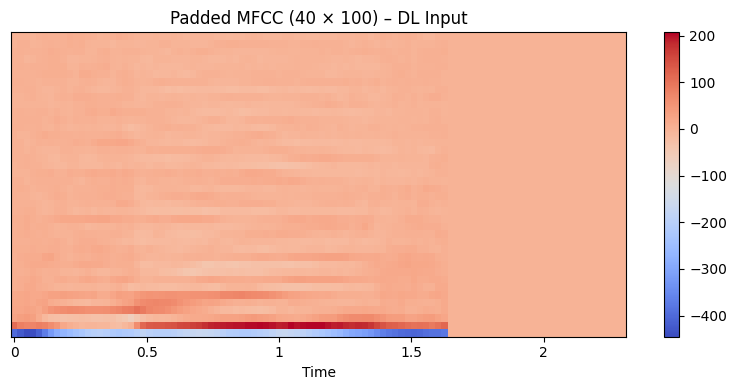

In [ ]:
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
librosa.display.specshow(
    mfcc_padded,
    x_axis="time"
)
plt.colorbar()
plt.title("Padded MFCC (40 × 100) – DL Input")
plt.tight_layout()
plt.show()


In [170]:
import numpy as np
import os

X_dl = []
y_dl = []

for file in wav_files:
    X_dl.append(extract_mfcc_dl(file))
    y_dl.append(int(os.path.basename(file).split("_")[0]))

X_dl = np.array(X_dl)
y_dl = np.array(y_dl)

print("X_dl shape:", X_dl.shape)
print("y_dl shape:", y_dl.shape)

X_dl shape: (30000, 40, 100)
y_dl shape: (30000,)


## CNN

In [171]:
X_dl = np.array(X_dl)
X_cnn = X_dl[..., np.newaxis]
y_cnn = y

print("CNN input shape:", X_cnn.shape)

CNN input shape: (30000, 40, 100, 1)


In [175]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn,
    y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn
)

print(X_train.shape, X_test.shape)


(24000, 40, 100, 1) (6000, 40, 100, 1)


In [179]:
num_speakers = len(np.unique(y_cnn))
print(num_speakers)   # should be 60

60


In [180]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(40,100,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_speakers, activation="softmax")  # ✅ FIXED
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 38, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 38, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 19, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 17, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 23, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 21, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 21, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 10, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       983,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 60)             │        15,420 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,092,284 (4.17 MB)

 Trainable params: 1,091,836 (4.17 MB)

 Non-trainable params: 448 (1.75 KB)

In [181]:
cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 76s 191ms/step - accuracy: 0.4868 - loss: 1.9812 - val_accuracy: 0.8803 - val_loss: 0.4183
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 189ms/step - accuracy: 0.9049 - loss: 0.3123 - val_accuracy: 0.9632 - val_loss: 0.1302
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 72s 191ms/step - accuracy: 0.9565 - loss: 0.1384 - val_accuracy: 0.9767 - val_loss: 0.0783
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 102s 272ms/step - accuracy: 0.9673 - loss: 0.1050 - val_accuracy: 0.9772 - val_loss: 0.0786
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 72s 190ms/step - accuracy: 0.9740 - loss: 0.0793 - val_accuracy: 0.9847 - val_loss: 0.0589
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 72s 190ms/step - accuracy: 0.9785 - loss: 0.0696 - val_accuracy: 0.9770 - val_loss: 0.0822
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 75s 199ms/step - accuracy: 0.9788 - loss: 0.0702 - val_accuracy: 0.9837 - val_loss: 0.0614
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 190ms/step - accuracy: 0.9811 - loss: 

In [183]:
import numpy as np
from sklearn.metrics import accuracy_score

# Predict
y_pred_cnn = cnn_model.predict(X_test)
y_pred_cnn = np.argmax(y_pred_cnn, axis=1)

# Accuracy
cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
print("CNN Speaker Accuracy:", cnn_accuracy)


188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
CNN Speaker Accuracy: 0.9918333333333333


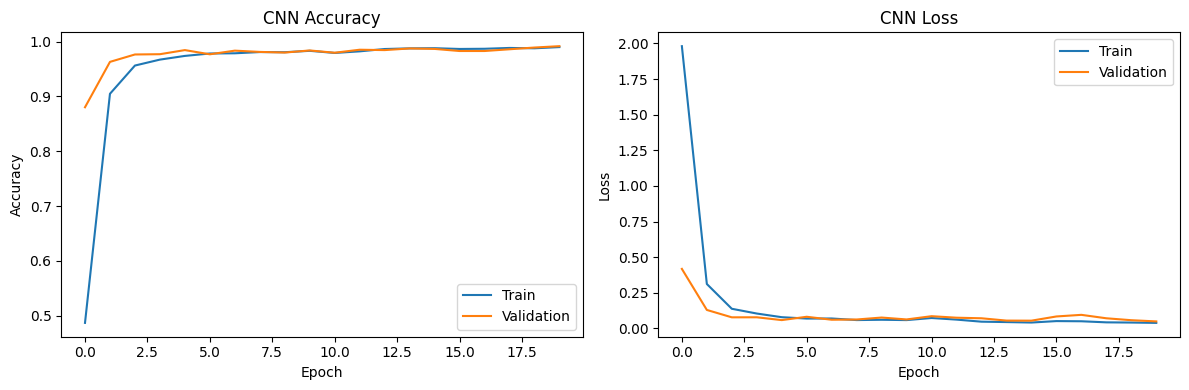

In [184]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(cnn.history["accuracy"], label="Train")
plt.plot(cnn.history["val_accuracy"], label="Validation")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(cnn.history["loss"], label="Train")
plt.plot(cnn.history["val_loss"], label="Validation")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [185]:
from sklearn.metrics import accuracy_score, classification_report

cnn_accuracy = accuracy_score(y_test, y_pred_cnn)

print("CNN Accuracy:", cnn_accuracy)
print("\nCNN Classification Report:\n")
print(classification_report(y_test, y_pred_cnn))

CNN Accuracy: 0.9918333333333333

CNN Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       100
           1       0.99      1.00      1.00       100
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00       100
           4       0.99      1.00      1.00       100
           5       0.99      1.00      1.00       100
           6       0.99      0.98      0.98       100
           7       1.00      1.00      1.00       100
           8       1.00      1.00      1.00       100
           9       1.00      1.00      1.00       100
          10       0.99      1.00      1.00       100
          11       1.00      1.00      1.00       100
          12       1.00      0.99      0.99       100
          13       1.00      0.98      0.99       100
          14       1.00      0.99      0.99       100
          15       1.00      0.99      0.99       100
          16       

In [214]:
from sklearn.metrics import precision_score, recall_score, f1_score

cnn_precision = precision_score(y_test, y_pred_cnn, average="macro")
cnn_recall    = recall_score(y_test, y_pred_cnn, average="macro")
cnn_f1        = f1_score(y_test, y_pred_cnn, average="macro")

print("CNN Accuracy:", cnn_accuracy)
print("CNN Precision:", cnn_precision)
print("CNN Recall:", cnn_recall)
print("CNN F1-score:", cnn_f1)

CNN Accuracy: 0.9918333333333333
CNN Precision: 0.9919513790950018
CNN Recall: 0.9918333333333335
CNN F1-score: 0.99184086541805


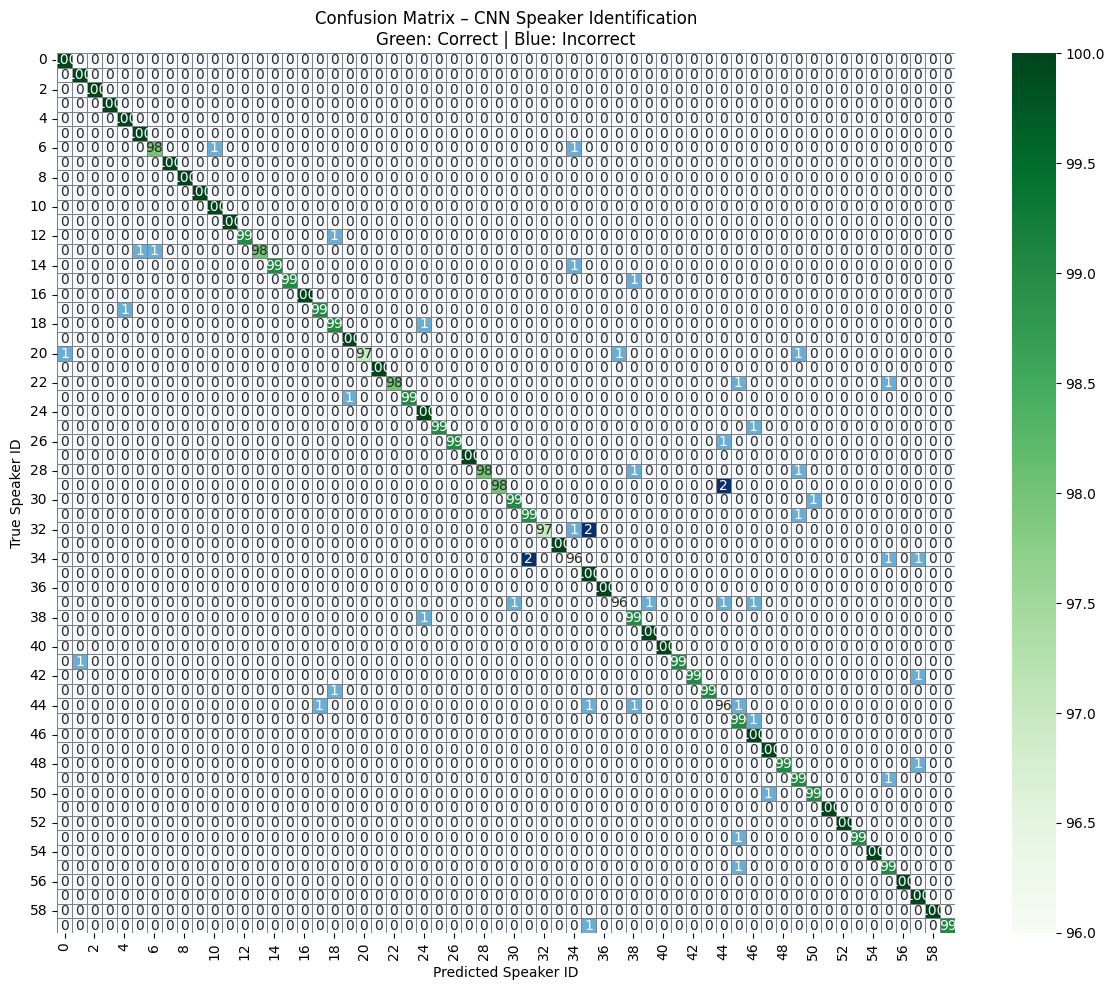

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
labels = np.unique(y_test)
diag = np.eye(cm_cnn.shape[0], dtype=bool)

plt.figure(figsize=(12,10))

# Correct predictions → GREEN (diagonal)
sns.heatmap(
    cm_cnn,
    mask=~diag,
    cmap="Greens",
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.4,
    linecolor="gray"
)

# Incorrect predictions → BLUE (off-diagonal)
sns.heatmap(
    cm_cnn,
    mask=diag,
    cmap="Blues",
    annot=True,
    fmt="d",
    cbar=False,
    linewidths=0.4,
    linecolor="gray"
)

plt.xlabel("Predicted Speaker ID")
plt.ylabel("True Speaker ID")
plt.title("Confusion Matrix – CNN Speaker Identification\nGreen: Correct | Blue: Incorrect")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [189]:
model_scores["CNN"] = cnn_accuracy

results_df = pd.DataFrame.from_dict(
    model_scores,
    orient="index",
    columns=["Accuracy"]
).sort_values(by="Accuracy", ascending=False)

results_df

,Accuracy
SVM (RBF),0.998500
KNN,0.993500
CNN,0.991833
Random Forest,0.991500


## LSTM

In [191]:
import numpy as np

X_lstm = np.transpose(X_dl, (0, 2, 1))  # (samples, 100, 40)

print("X_lstm shape:", X_lstm.shape)


X_lstm shape: (30000, 100, 40)


In [192]:
mean = X_lstm.mean(axis=(0, 1), keepdims=True)
std  = X_lstm.std(axis=(0, 1), keepdims=True) + 1e-8

X_lstm_norm = (X_lstm - mean) / std

print("X_lstm_norm shape:", X_lstm_norm.shape)


X_lstm_norm shape: (30000, 100, 40)


In [195]:
from sklearn.model_selection import train_test_split

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_lstm_norm,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train_lstm.shape, X_test_lstm.shape)


(24000, 100, 40) (6000, 100, 40)


In [199]:
import numpy as np
from tensorflow.keras import layers, models

num_speakers = len(np.unique(y))  # ✅ correct

lstm_model = models.Sequential([
    layers.LSTM(128, input_shape=(100, 40)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_speakers, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 60)             │         7,740 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,780 (432.73 KB)

 Trainable params: 110,780 (432.73 KB)

 Non-trainable params: 0 (0.00 B)

In [200]:
lstm = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=20,
    batch_size=64
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.0542 - loss: 3.7144 - val_accuracy: 0.1465 - val_loss: 3.0348
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.2313 - loss: 2.6198 - val_accuracy: 0.3860 - val_loss: 1.9919
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.4713 - loss: 1.7095 - val_accuracy: 0.5922 - val_loss: 1.3299
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.6890 - loss: 1.0240 - val_accuracy: 0.7943 - val_loss: 0.7152
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.8085 - loss: 0.6731 - val_accuracy: 0.8545 - val_loss: 0.5291
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.8746 - loss: 0.4421 - val_accuracy: 0.8970 - val_loss: 0.3579
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.9192 - loss: 0.2907 - val_accuracy: 0.9237 - val_loss: 0.2854
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.9433 - loss: 0.2109 - 

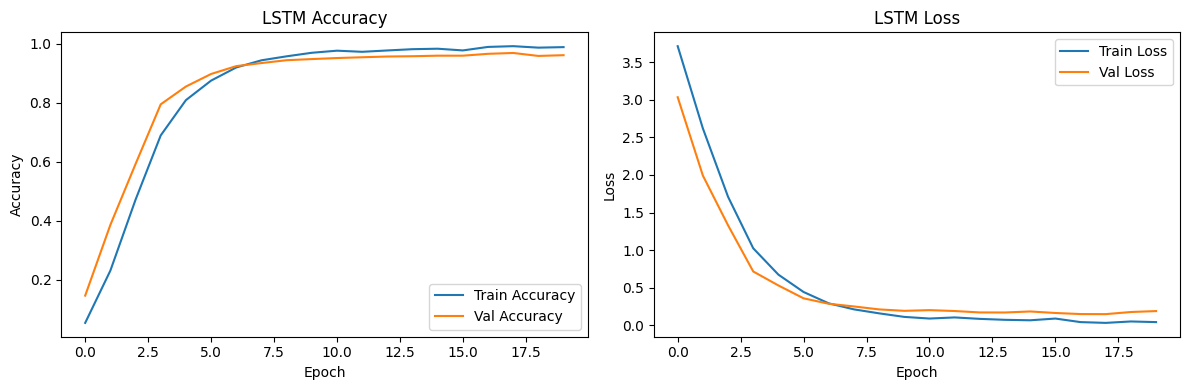

In [202]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(lstm.history["accuracy"], label="Train Accuracy")
plt.plot(lstm.history["val_accuracy"], label="Val Accuracy")
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(lstm.history["loss"], label="Train Loss")
plt.plot(lstm.history["val_loss"], label="Val Loss")
plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

y_pred_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_pred_lstm, axis=1)

lstm_accuracy = accuracy_score(y_test_lstm, y_pred_lstm)


188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
LSTM Speaker Accuracy: 0.9606666666666667


In [ ]:
from sklearn.metrics import classification_report

print("\nLSTM Classification Report:\n")
print(classification_report(y_test_lstm, y_pred_lstm))
print("LSTM Speaker Accuracy:", lstm_accuracy)



LSTM Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.94      0.97      0.96       100
           2       0.96      0.99      0.98       100
           3       0.99      0.99      0.99       100
           4       0.95      0.98      0.97       100
           5       1.00      0.95      0.97       100
           6       0.98      0.95      0.96       100
           7       0.99      0.99      0.99       100
           8       0.99      1.00      1.00       100
           9       0.88      0.99      0.93       100
          10       1.00      0.99      0.99       100
          11       1.00      0.97      0.98       100
          12       1.00      0.95      0.97       100
          13       0.99      0.89      0.94       100
          14       0.99      0.95      0.97       100
          15       0.99      1.00      1.00       100
          16       0.96      0.96      0.96       1

In [216]:
lstm_precision =precision_score(y_test, y_pred_lstm, average="macro")
lstm_recall   = recall_score(y_test, y_pred_lstm, average="macro")
lstm_f1   = f1_score(y_test, y_pred_lstm, average="macro")


print("LSTM Speaker Accuracy:", lstm_accuracy)
print("LSTM Precision",lstm_precision)
print("LSTMall:", lstm_recall)
print("LSTMscore:", lstm_f1)

LSTM Speaker Accuracy: 0.9606666666666667
LSTM Precision 0.9615368506453701
LSTMall: 0.9606666666666666
LSTMscore: 0.9605315944398498


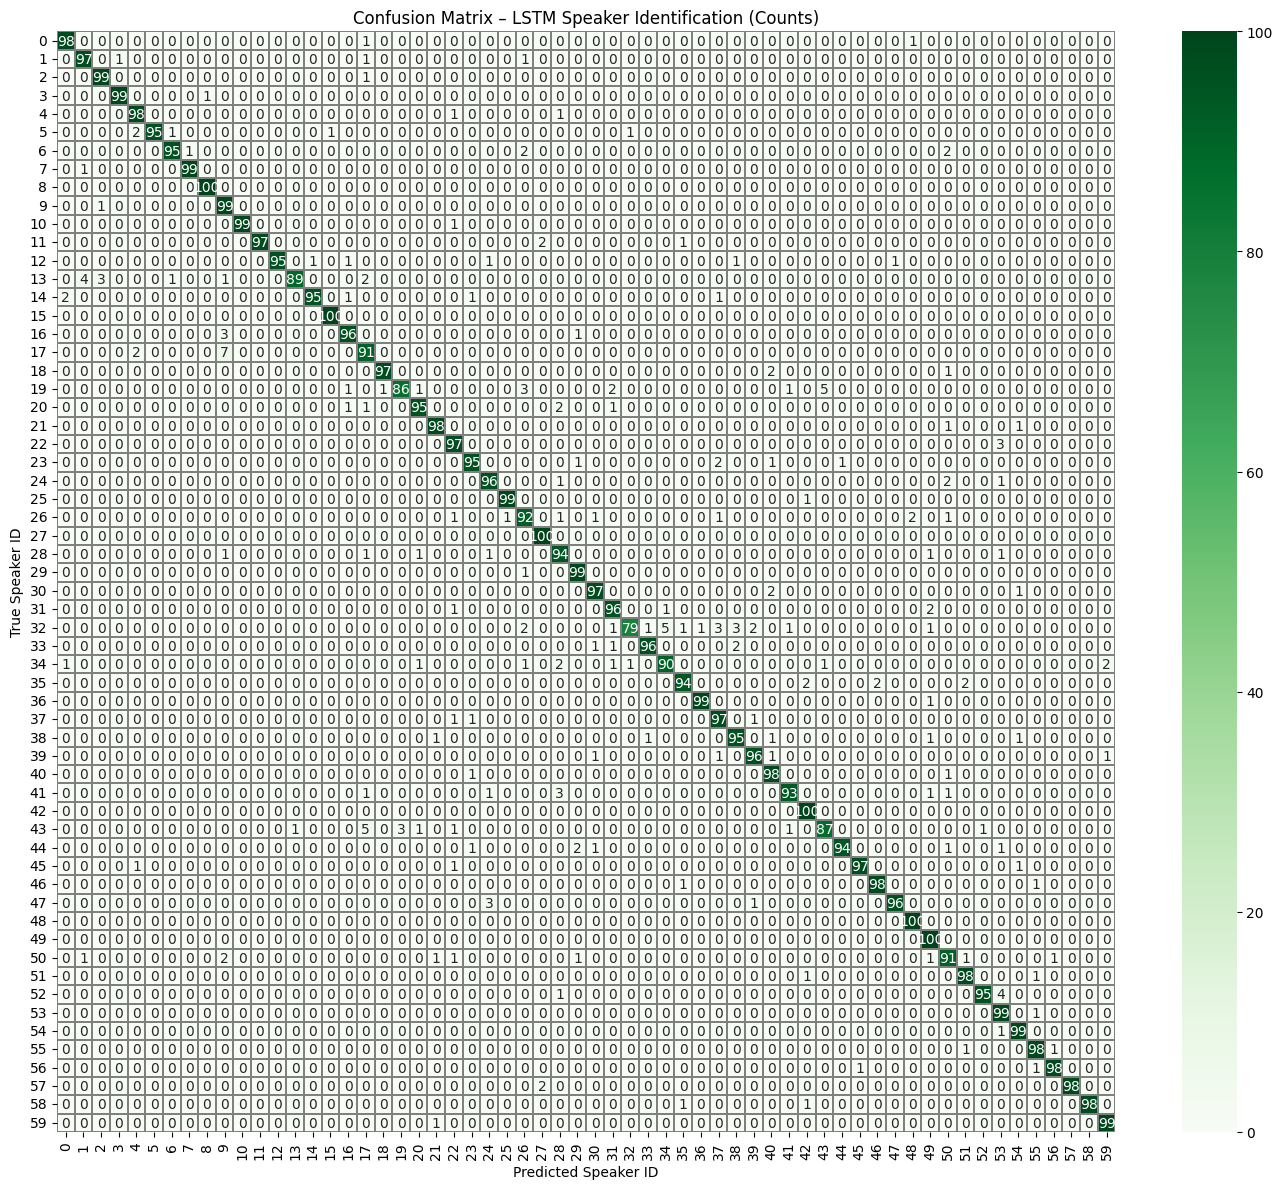

In [207]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix (COUNTS)
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
labels = np.unique(y_test_lstm)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_lstm,
    cmap="Greens",
    annot=True,          # 🔑 SHOW COUNTS
    fmt="d",             # integer counts
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.3,
    linecolor="gray",
    cbar=True
)

plt.xlabel("Predicted Speaker ID")
plt.ylabel("True Speaker ID")
plt.title("Confusion Matrix – LSTM Speaker Identification (Counts)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


The LSTM significantly outperforms the Simple RNN by effectively capturing long-term temporal dependencies in MFCC sequences, validating the importance of gated recurrent architectures for speech recognition.

## Comparing Models

In [211]:
import pandas as pd
import matplotlib.pyplot as plt

# Collect accuracies
model_scores = {
    "SVM (RBF)": svm_accuracy,
    "KNN": knn_accuracy,
    "Random Forest": rf_accuracy,
    "CNN": cnn_accuracy,
    "LSTM": lstm_accuracy
}

# Create DataFrame
results_df = pd.DataFrame.from_dict(
    model_scores,
    orient="index",
    columns=["Accuracy"]
).sort_values(by="Accuracy", ascending=False)

print("===== MODEL COMPARISON (ACCURACY) =====")
print(results_df)


===== MODEL COMPARISON (ACCURACY) =====
               Accuracy
SVM (RBF)      0.998500
KNN            0.993500
CNN            0.991833
Random Forest  0.991500
LSTM           0.960667


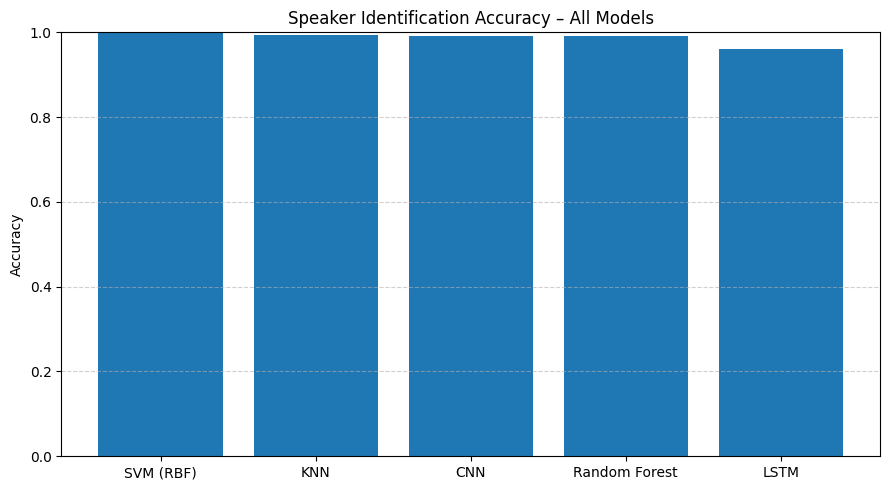

In [212]:
plt.figure(figsize=(9,5))
plt.bar(results_df.index, results_df["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Speaker Identification Accuracy – All Models")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()